In [1]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.interpolate import interp1d

In [2]:
# ExperimentoConstantes y parametros
m_cil=310.0 # [kg] - Masa del cilindro
D1=5.72e-2 # [m] - Diametro del cilindro
R_cil=D1/2 # [m] - Radio del cilindro
M_peso=23# [kg] - Masa del contrapeso
g=9.78 # [m/s^2] - gravedad en Bogota
c_al=0.22 # [cal/g*Celsius] - calor especifico del aluminio
J_teo=4.186 # J/cal

In [3]:
# TABLA R vs T DEL TERMISTOR
tabla_R = np.array([
    351020,332640,315320,298990,283600,269080,255380,242460,230260,218730,
    207850,197560,187840,178650,169950,161730,153950,146580,139610,133000,
    126740,120810,115190,109850,104800,100000,95447,91126,87022,83124,
    79422,75903,72560,69380,66356,63480,60743,58138,55658,53297,
    51048,48905,46863,44917,43062,41292,39605,37995,36458,34991,
    33591,32253,30976,29756,28590,27475,26409,25390,24415,23483,
    22590,21736,20919,20136,19386,18668,17980,17321,16689,16083,
    15502,14945,14410,13897,13405,12932,12479,12043,11625,11223,
    10837,10467,10110,9767.2,9437.7,9120.8,8816.0,8522.7,8240.6,7969.1,
    7707.7,7456.2,7214.0,6980.6,6755.9,6539.4,6330.8,6129.8,5936.1,5749.3,5569.3
])
tabla_T = np.arange(0, 101)

In [4]:
# Interpolador de la curva
R_to_T = interp1d(tabla_R[::-1], tabla_T[::-1], kind='linear', fill_value='extrapolate')

In [5]:
# Carga de datos
df1=pd.read_csv("datos1.csv")
df2=pd.read_csv("datos2.csv")

In [6]:
# Calculo del equivalente para el calculo del calor mecanico
df1["res"]=df1["res"]
df1["T_C"]=R_to_T(df1["res"])
T_i=df1["T_C"].iloc[0]
T_f=df1["T_C"].iloc[-1]
dT=T_f-T_i
N_tot=df1["vueltas"].iloc[-1]
print(T_i, T_f)

2.0 40.0


Para calcular el trabajo, usamos la siguiente relacion: 
$$
W_J=M_{contrapeso}gR(2\pi N)
$$

In [7]:
# Calculo del trabajo en Joules
W_J=M_peso*g*R_cil*2*np.pi*N_tot

Sabemos que el calor estara dado por: 
$$
Q=m_{cilindro}c_{al}\Delta T
$$

In [8]:
Q_cal=m_cil*c_al*dT

Finalmente, sabemos que el equivalente mecanico del calor sera: 
$$
J = \frac{W}{Q}
$$

In [9]:
# equivalente mecanico experimental
J_exp=W_J/Q_cal
# calculo del error:
error_J=abs(J_exp-J_teo) / J_teo * 100

print(f"  T_inicial   = {T_i:.2f} °C")
print(f"  T_final     = {T_f:.2f} °C")
print(f"  ΔT          = {dT:.2f} °C")
print(f"  N_total     = {N_tot} vueltas")
print(f"  W           = {W_J:.2f} J")
print(f"  Q           = {Q_cal:.4f} cal")
print(f"  J_exp       = {J_exp:.4f} J/cal")
print(f"  J_teórico   = {J_teo:.4f} J/cal")
print(f"  Error       = {error_J:.2f}%")

  T_inicial   = 2.00 °C
  T_final     = 40.00 °C
  ΔT          = 38.00 °C
  N_total     = 200 vueltas
  W           = 8084.30 J
  Q           = 2591.6000 cal
  J_exp       = 3.1194 J/cal
  J_teórico   = 4.1860 J/cal
  Error       = 25.48%


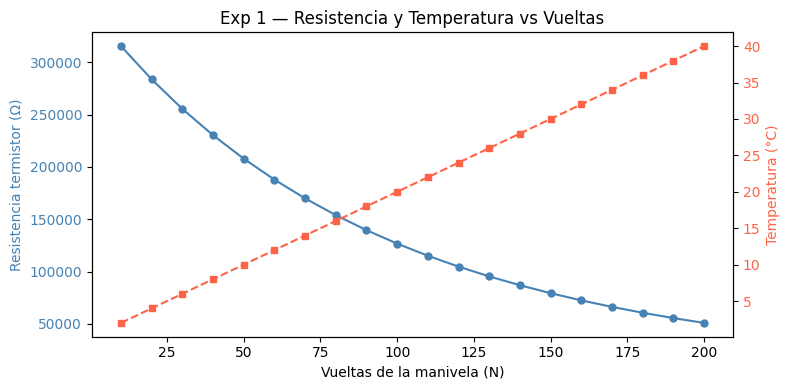

In [10]:
fig, ax1 = plt.subplots(figsize=(8, 4))
color_R, color_T = "steelblue", "tomato"

ax1.plot(df1["vueltas"], df1["res"], "o-", color=color_R, ms=5, label="Resistencia")
ax1.set_xlabel("Vueltas de la manivela (N)")
ax1.set_ylabel("Resistencia termistor (Ω)", color=color_R)
ax1.tick_params(axis="y", labelcolor=color_R)

ax2 = ax1.twinx()
ax2.plot(df1["vueltas"], df1["T_C"], "s--", color=color_T, ms=5, label="Temperatura")
ax2.set_ylabel("Temperatura (°C)", color=color_T)
ax2.tick_params(axis="y", labelcolor=color_T)

ax1.set_title("Exp 1 — Resistencia y Temperatura vs Vueltas")
fig.tight_layout()
plt.savefig("exp1_R_T_vs_vueltas.png", dpi=150)
plt.show()

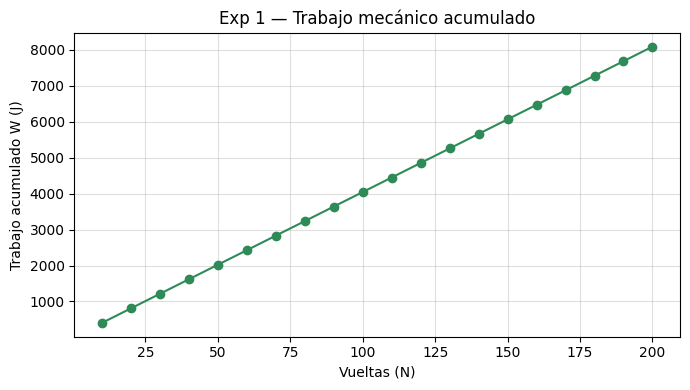

In [11]:
W_acum = M_peso * g * R_cil * 2 * np.pi * df1["vueltas"].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df1["vueltas"], W_acum, "o-", color="seagreen")
ax.set_xlabel("Vueltas (N)")
ax.set_ylabel("Trabajo acumulado W (J)")
ax.set_title("Exp 1 — Trabajo mecánico acumulado")
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.savefig("exp1_trabajo_acumulado.png", dpi=150)
plt.show()

## Experimento 2 - CALORIMETRO: T vs t

In [12]:
# Constantes y parametros para experimento 2. 
m_eq   = 337.68         # g  — masa equivalente del calorimetro
c_agua = 1.0            # cal/(g·°C)
P_nom  = 16*4           # W

In [13]:
t=df2["time[min]"].values
T=df2["temperature"].values

slope, intercept, r_val, _, se=linregress(t,T)
T_fit = slope*t + intercept

In [14]:
#potencia absorbida
P_real=m_eq*c_agua*slope*J_teo/60
eficiencia=P_real/P_nom*100
print(f"  dT/dt (pendiente) = {slope:.4f} °C/min")
print(f"  R²                = {r_val**2:.5f}")
print(f"  Potencia absorbida = {P_real:.3f} W")
print(f"  Potencia nominal   = {P_nom:.1f} W")
print(f"  Eficiencia         = {eficiencia:.1f}%")

  dT/dt (pendiente) = 2.1608 °C/min
  R²                = 0.99699
  Potencia absorbida = 50.907 W
  Potencia nominal   = 64.0 W
  Eficiencia         = 79.5%


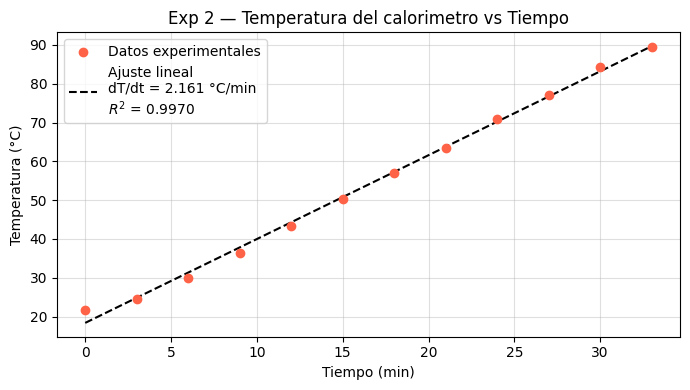

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(t, T, color="tomato", zorder=5, label="Datos experimentales")
ax.plot(t, T_fit, "k--",
        label=f"Ajuste lineal\ndT/dt = {slope:.3f} °C/min\n$R^2$ = {r_val**2:.4f}")
ax.set_xlabel("Tiempo (min)")
ax.set_ylabel("Temperatura (°C)")
ax.set_title("Exp 2 — Temperatura del calorimetro vs Tiempo")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.savefig("exp2_T_vs_t.png", dpi=150)
plt.show()